Hello! This is program is used for planetary visibilityYou can input a date and time, and the program will calculate which planets are visible from your location at that time. (The only location available right now is Leiden)It will also generate a sky map showing the paths of the planets over the next 14 days!You can track the planets in the sky and see which constellations they are in. Enjoy!


Please enter a date and time in the next format without the brackets: (YYYY-MM-DD HH:MM:SS). E.g., 2026-03-17 20:00:00  2026-03-17 00:00:00


Nice, date set to: 2026-03-17 00:00:00.000
Planet Mercury isn't observable right now.
Planet Venus isn't observable right now.
Planet Mars isn't observable right now.
Planet Jupiter is observable at alt = 27.61 deg and az = 272.49 deg in constellation Gemini.
Planet Saturn isn't observable right now.
Planet Uranus isn't observable right now.
Planet Neptune isn't observable right now.


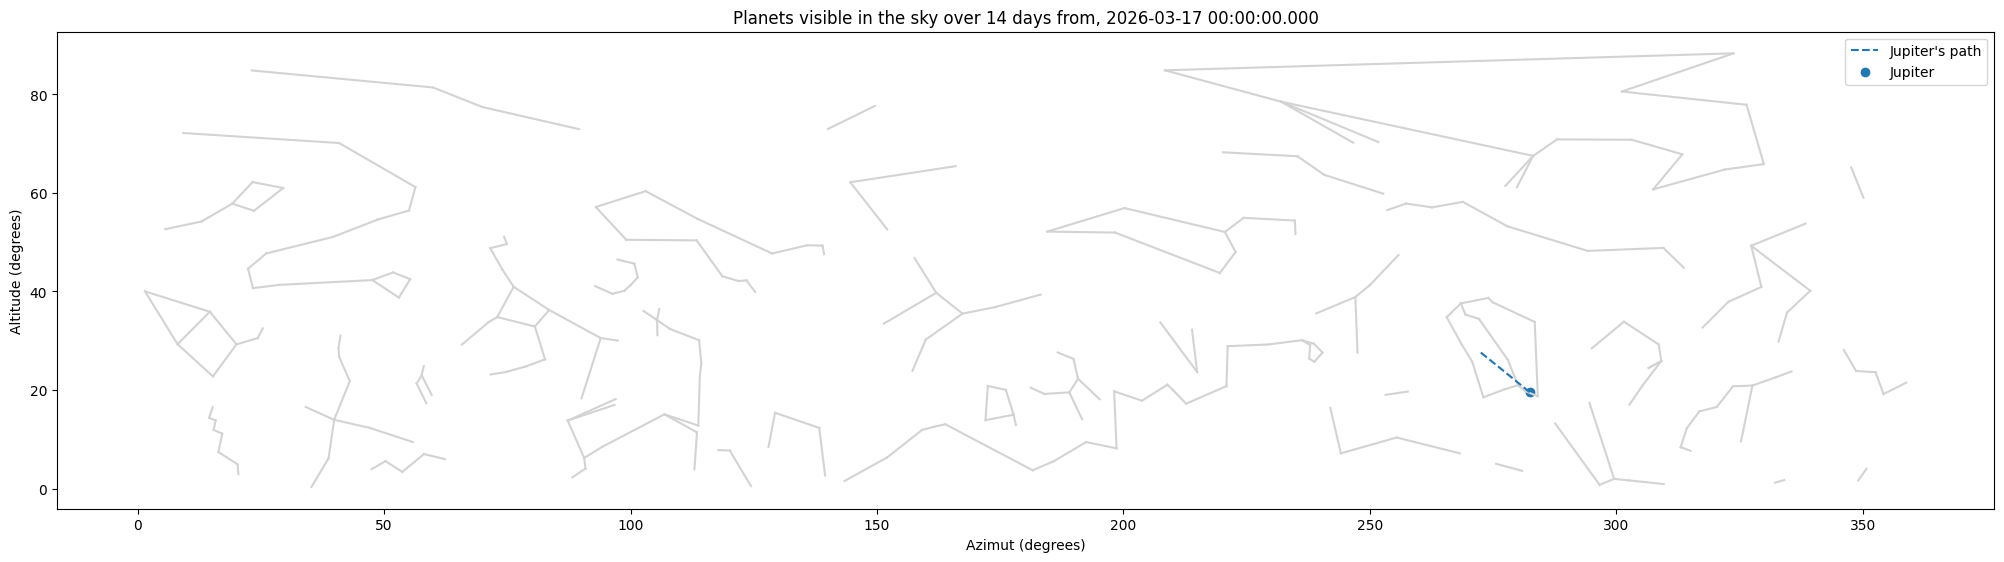

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
import astropy.time as time
import astropy.coordinates as coords


print("Hello! " \
"This is program is used for planetary visibility"\
"You can input a date and time, and the program will calculate which planets are visible from your location at that time. (The only location available right now is Leiden)" \
"It will also generate a sky map showing the paths of the planets over the next 14 days!"\
"You can track the planets in the sky and see which constellations they are in. Enjoy!")

#*data*

while True:
    user_input = input("Please enter a date and time in the next format without the brackets: (YYYY-MM-DD HH:MM:SS). E.g., 2026-03-17 20:00:00 ")
    try:
        date = time.Time(user_input)
        print(f"Nice, date set to: {date}")
        break
    except ValueError:
        print("Invalid format. Please try again.")
location = coords.EarthLocation(lat=52.2*u.deg, lon=5.9*u.deg, height=0*u.m) #location of the observer
planets = ['Mercury', 'Venus', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune'] #list of objects to observe
altaz_coords = coords.AltAz(obstime=date, location=location) #creating AltAz coordinatess for the observation time and location

#*checking whether planets are observable and where. See data as the reference point*
for p in planets:
    p_coord = coords.get_body(p, date, location) #gets the coordinates of the planet at the observation time and location
    altaz = p_coord.transform_to(altaz_coords) #converting the equatorial coordinates to Altaz (horizon) coordinates
    if altaz.alt > 0*u.deg: #checks if the planet is above the horizon
        print(f"Planet {p} is observable at alt = {altaz.alt:.2f} and az = {altaz.az:.2f} in constellation {coords.get_constellation(p_coord)}.")
    else:
        print(f"Planet {p} isn't observable right now.")

#*plotting the planets their paths over 14 days with constellations*

#creating an array of dates for the next 14 days at 8pm
dates = date + np.arange(0, 14 + 1, 1)*u.day 
#importing constellation data from the given txt file
ra_stars, dec_stars, pen = np.loadtxt('Database.txt', usecols=(2, 3, 4), unpack=True) #using only the columns who are useful (RA, Dec, and whether to draw a line)
#converting the RA and Dec coordinates to degrees
ra_stars = ra_stars*u.deg 
dec_stars = dec_stars*u.deg
#creating SkyCoords for the stars
star_coords = coords.SkyCoord(ra=ra_stars, dec=dec_stars) 
#converting the star coordinates to AltAz for the observation time and location
star_altaz = star_coords.transform_to(altaz_coords)

#-plotting the constellations in the 'background' of the plot-

plt.figure(figsize=(25, 10)) #making it extra large for better visibility
for i in range(0, len(star_altaz)): #looping through the stars
    if pen[i] == 1: #if pen is 1, draw a line to the next star
        x1, x2 = [star_altaz[i-1].az.deg, star_altaz[i].az.deg] #x coordinates of the line
        y1, y2 = [star_altaz[i-1].alt.deg, star_altaz[i].alt.deg] #y coordinates of the line
        if abs(x1-x2) < 180: #removing the horizontal lines from x = 0 to x = 360
            if y1 > 0 and y2 > 0: #removing all the stars/constelations that are below the horizon
                plt.plot([x1, x2], [y1, y2], color='lightgray') #plot the line between the stars in light gray

#-plotting the planets with their path in a timespan of 14 days-

for p in planets: #looping through the planets
    p_coords = coords.get_body(p, dates, location) #gets the coordinates of the planet for the next 14 days
    p_altaz = p_coords.transform_to(coords.AltAz(obstime=dates, location=location)) #converting the equatorial coordinates to Altaz (horizon) coordinates based on the observation time and location
    horizon = p_altaz.alt > 0*u.deg #only plot the planet if it's above the horizon
    if horizon.any(): #if the planet is visible at any time during the 14 days
        #plotting its path in the sky with a dashed line.
        plt.plot(p_altaz.az.deg[horizon], p_altaz.alt.deg[horizon], 
                 linestyle='--', label=f"{p}'s path")
        if horizon[-1]: #if the planet is visible at the last observation time, plot a circle
            plt.scatter(p_altaz.az.deg[-1], p_altaz.alt.deg[-1], label=p)
plt.title(f'Planets visible in the sky over 14 days from, {date}')
plt.xlabel('Azimut (degrees)')
plt.ylabel('Altitude (degrees)')
plt.gca().set_aspect('equal') #setting the axes to be equal
plt.legend()
plt.show()